https://www.perplexity.ai/search/you-are-a-python-instructor-fo-D8PzUjQ8SEC1obKOCCZ2vg#10

# NumPy, Pandas, and Stats

This notebook demonstrates how NumPy, Pandas, and Statsmodels can be used together for advanced data analytics.   
We will:
- Create synthetic weather data using NumPy.
- Perform statistical exploration, merging, and grouping using Pandas.
- Use Seaborn and Matplotlib for data visualization.
- Build regression models and evaluate them visually and statistically.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set(style='whitegrid', palette='muted')

## 1. Creating Synthetic Weather Data

We generate 30 days of weather data using NumPy random functions:
https://numpy.org/doc/2.1/reference/random/index.html#random-quick-start
"The numpy.random module implements pseudo-random number generators (PRNGs or RNGs, for short) with the ability to draw samples from a variety of probability distributions. In general, users will create a Generator instance with default_rng and call the various methods on it to obtain samples from different distributions."

- `np.random.default_rng()` creates a random `numpy.random.Generator` instance
- `rg.normal(loc, scale, size)` draws `size` random samples from a normal (Gaussian) distribution with `loc` mean and `scale` standard deviation.
- `rg.uniform(low, high, size)` produces `size` uniformly distributed random numbers within the interval [`low`,`high`).
- `np.mean(arr)` computes the array mean
- `np.std(arr)` computes the array stadard deviation

Vectorized NumPy operations allow direct arithmetic over entire arrays, giving highly efficient calculations.


In [2]:
np.random.seed(42)
days = np.arange(1, 31)
rg = np.random.default_rng()
temperatures = rg.normal(loc=25, scale=3, size=30)
humidity = rg.uniform(low=30, high=80, size=30)
# use a formula for the heat index
heat_index = temperatures + 0.1 * humidity

print('Temperature Statistics:')
print(f'Mean: {np.mean(temperatures):.2f}') # the .2f used in the f-string will format flots to use 2 decimals
print(f'Standard deviation: {np.std(temperatures):.2f}')

Temperature Statistics:
Mean: 24.38
Standard deviation: 3.35


## 2. Creating and Merging DataFrames

We create two DataFrames and merge them using Pandas.  
In this example, we merge event data with daily weather.   
We use a left join to only add the event to the weather data where event data exists.


In [3]:
df_weather = pd.DataFrame({
    'Day': days,
    'Temperature': temperatures,
    'Humidity': humidity,
    'Heat_Index': heat_index
})
# display only the first 5 rows - we have 30 in total
print("Numer of rows and columns:", df_weather.shape)
print("First 5 rows:")
df_weather.head()

Numer of rows and columns: (30, 4)
First 5 rows:


,Day,Temperature,Humidity,Heat_Index
0,1,30.631635,76.812238,38.312859
1,2,23.202566,58.001109,29.002677
2,3,22.208201,54.125889,27.620790
3,4,25.399443,69.488235,32.348267
4,5,22.471499,36.678495,26.139349


In [4]:
df_events = pd.DataFrame({
    'Day': [5, 10, 15, 20, 25],
    'Event': ['Storm', 'Festival', 'Maintenance', 'Seminar', 'Holiday']
})
df_events

,Day,Event
0,5,Storm
1,10,Festival
2,15,Maintenance
3,20,Seminar
4,25,Holiday


### `pd.merge()` Parameters:
- `on`: column to join on.
- `how`: type of join — `'inner'`, `'left'`, `'right'`, `'outer'`.
- `left` and `right`: DataFrames being merged.
- `suffixes`: labels to apply if overlapping columns exist.


In [5]:
df_merged = pd.merge(df_weather, df_events, on='Day', how='left')
df_merged

,Day,Temperature,Humidity,Heat_Index,Event
0,1,30.631635,76.812238,38.312859,NaN
1,2,23.202566,58.001109,29.002677,NaN
2,3,22.208201,54.125889,27.620790,NaN
3,4,25.399443,69.488235,32.348267,NaN
4,5,22.471499,36.678495,26.139349,Storm
5,6,18.496231,30.416798,21.537911,NaN
6,7,19.555095,79.838488,27.538944,NaN
7,8,23.949083,32.083346,27.157417,NaN
8,9,22.685239,75.504291,30.235668,NaN
9,10,25.033650,75.094114,32.543062,Festival


## 3. Temperature Categories and Grouped Aggregations

We classify temperatures into quantile-based bins using `pd.qcut()`.

- `pd.qcut(x, q, labels)`: divides numerical data into equal-sized quantiles.
- The `groupby()` and `agg()` functions summarize grouped statistics.
   - `.groupby('column')` groups the data by category.
   - `.agg(['mean', 'std', 'min', 'max'])` computes multiple aggregation metrics simultaneously.


In [6]:
# add a new column with category data based on the temperature value
df_merged['Temp_Category'] = pd.qcut(df_merged['Temperature'], q=3, labels=['Cool', 'Moderate', 'Hot'])

# group data by temp category and compute various stats for the heat index and humidity
group_stats = df_merged.groupby('Temp_Category', observed = True)[['Heat_Index', 'Humidity']].agg(['mean', 'std', 'min', 'max'])
group_stats

Heat_Index                                   Humidity  \
                    mean       std        min        max       mean   
Temp_Category                                                         
Cool           26.669520  2.352794  21.537911  30.235668  56.506833   
Moderate       29.434660  2.317178  25.935175  32.543062  55.292259   
Hot            33.878091  3.037282  30.918119  40.175725  56.703474   

                                                
                     std        min        max  
Temp_Category                                   
Cool           20.843364  30.416798  79.838488  
Moderate       16.914856  32.083346  77.792138  
Hot            16.181967  36.652219  79.842743

In [7]:
# see the temp category data included
df_merged

,Day,Temperature,Humidity,Heat_Index,Event,Temp_Category
0,1,30.631635,76.812238,38.312859,NaN,Hot
1,2,23.202566,58.001109,29.002677,NaN,Moderate
2,3,22.208201,54.125889,27.620790,NaN,Cool
3,4,25.399443,69.488235,32.348267,NaN,Hot
4,5,22.471499,36.678495,26.139349,Storm,Cool
5,6,18.496231,30.416798,21.537911,NaN,Cool
6,7,19.555095,79.838488,27.538944,NaN,Cool
7,8,23.949083,32.083346,27.157417,NaN,Moderate
8,9,22.685239,75.504291,30.235668,NaN,Cool
9,10,25.033650,75.094114,32.543062,Festival,Moderate


## 4. Visualization Techniques Explained

We use Seaborn and Matplotlib for plotting. Here’s what each function does:

### 1. `sns.scatterplot()`
- Plots two continuous variables against each other.
- Common parameters:
  - `x`, `y`: data columns.
  - `hue`: categorical column to color-code points.
  - `s`: size of the markers.
  - `data`: DataFrame containing columns.

### 2. `sns.histplot()`
- Displays the frequency distribution of a variable.
- `kde=True` overlays a smooth Kernel Density Estimate curve.
- Useful parameters:
  - `bins`: number of histogram bins.
  - `color`: bar color.

### 3. `sns.boxplot()`
- Shows data dispersion and outliers across categorical groups.
- Displays median, quartiles, and potential outliers.
  - `x`: category variable.
  - `y`: quantitative variable.
  - `palette`: defines color scheme.

All of these provide visual summaries of data spread, variation, and correlation structures.


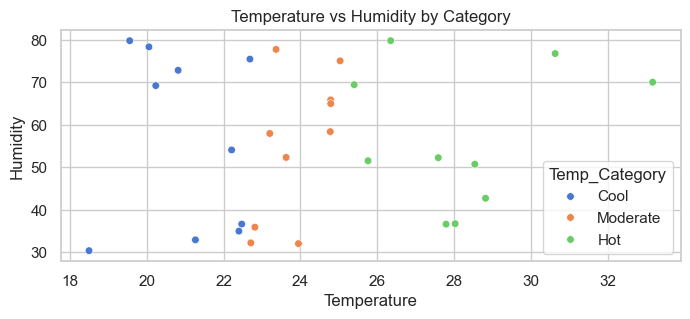

In [8]:
plt.figure(figsize=(8, 3))
sns.scatterplot(x='Temperature', y='Humidity', data=df_merged, hue='Temp_Category', s=30)
plt.title('Temperature vs Humidity by Category')
plt.show()



## 4. Visualization Techniques Explained

We use Seaborn and Matplotlib for plotting. Here’s what each function does:

### 1. `sns.scatterplot()`
- Plots two continuous variables against each other.
- Common parameters:
  - `x`, `y`: data columns.
  - `hue`: categorical column to color-code points.
  - `s`: size of the markers.
  - `data`: DataFrame containing columns.

### 2. `sns.histplot()`
- Displays the frequency distribution of a variable.
- `kde=True` overlays a smooth Kernel Density Estimate curve.
- Useful parameters:
  - `bins`: number of histogram bins.
  - `color`: bar color.


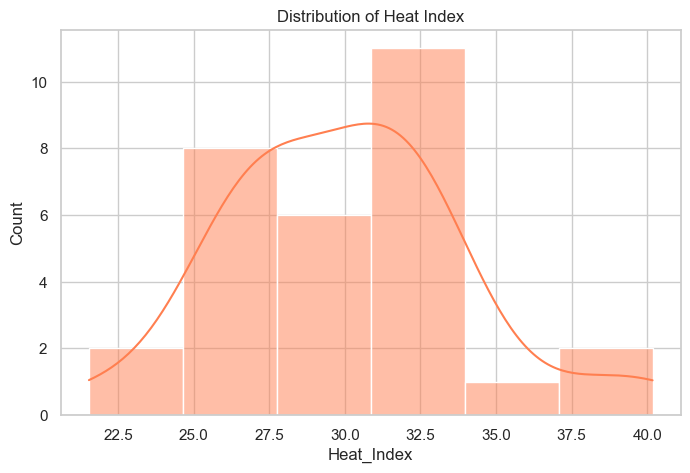

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df_merged['Heat_Index'], kde=True, color='coral')
plt.title('Distribution of Heat Index')
plt.show()

### 3. Compare the heat index accross the temperature categories
### `sns.boxplot()`
- Shows data dispersion and outliers across categorical groups.
- Displays median, quartiles, and potential outliers.
  - `x`: category variable.
  - `y`: quantitative variable.
  - `palette`: defines color scheme.


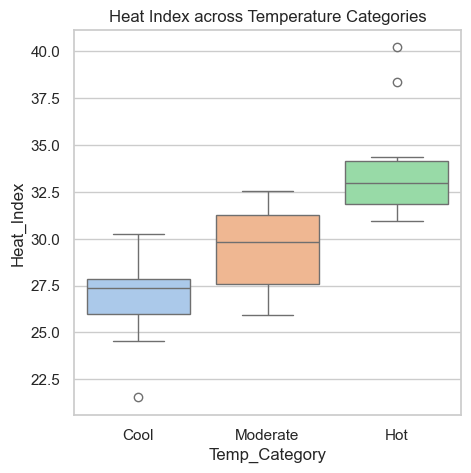

In [10]:
plt.figure(figsize=(5, 5))
sns.boxplot(x='Temp_Category', y='Heat_Index', data=df_merged, hue='Temp_Category', palette='pastel')
plt.title('Heat Index across Temperature Categories')
plt.show()

### 4. Check the association between the heat index and the temperature
### `sns.regplot()`
- Shows the linear relationship between two quantitative variables.
- It combines a scatter plot of the data points with a linear regression model fit to those points.
- Displays the data in a scatter plot, a regression line and the confidence interval around the regression line.
  - `x`,`y`: data columns - continuous numerical values.
  - `data`: DataFrame containing columns.


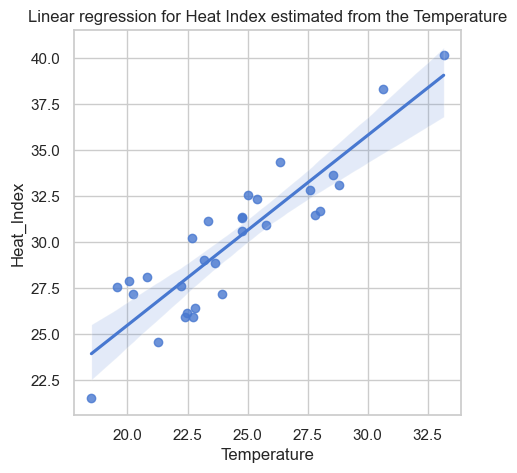

In [11]:
plt.figure(figsize=(5, 5))
sns.regplot(x='Temperature', y='Heat_Index', data=df_merged, )
plt.title('Linear regression for Heat Index estimated from the Temperature')
plt.show()

#### All of these examples provide visual summaries of data spread, variation, and correlation structures.


## 5. Linear Regression and Confidence Intervals

We use `Statsmodels`' **OLS** function for linear regression.

### Function: `smf.ols(formula, data)`
- `formula`: defines dependent and independent variables using symbolic syntax (`y ~ x1 + x2`).
- `data`: Pandas DataFrame providing variables.
- `.fit()`: estimates model parameters.

We then compute 95% confidence intervals and visualize regression relationships.


In [12]:
model = smf.ols('Temperature ~ Humidity', data=df_merged).fit()
print(model.summary())

predictions = model.get_prediction(df_merged)
pred_summary = predictions.summary_frame(alpha=0.05)

df_merged['Predicted_Temp'] = pred_summary['mean']
df_merged['CI_Lower'] = pred_summary['mean_ci_lower']
df_merged['CI_Upper'] = pred_summary['mean_ci_upper']

                            OLS Regression Results                            
Dep. Variable:            Temperature   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.032
Method:                 Least Squares   F-statistic:                    0.1049
Date:                Mon, 03 Nov 2025   Prob (F-statistic):              0.748
Time:                        08:58:36   Log-Likelihood:                -78.754
No. Observations:                  30   AIC:                             161.5
Df Residuals:                      28   BIC:                             164.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.7088      2.159     10.983      0.0

In [13]:
pred_summary

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,24.623078,0.987035,22.601228,26.644928,17.256788,31.989368
1,24.399164,0.634927,23.098575,25.699753,17.197366,31.600961
2,24.353036,0.635784,23.050691,25.655380,17.150921,31.555150
3,24.535898,0.798906,22.899414,26.172382,17.265930,31.805866
4,24.145354,0.954774,22.189589,26.101120,16.796928,31.493781
5,24.070820,1.137628,21.740494,26.401146,16.613959,31.527680
6,24.659100,1.074883,22.457303,26.860897,17.241401,32.076799
7,24.090657,1.087210,21.863609,26.317705,16.665424,31.515891
8,24.607509,0.950583,22.660327,26.554691,17.261362,31.953655
9,24.602626,0.939367,22.678420,26.526833,17.262536,31.942716


In [14]:
df_merged

,Day,Temperature,Humidity,Heat_Index,Event,Temp_Category,Predicted_Temp,CI_Lower,CI_Upper
0,1,30.631635,76.812238,38.312859,NaN,Hot,24.623078,22.601228,26.644928
1,2,23.202566,58.001109,29.002677,NaN,Moderate,24.399164,23.098575,25.699753
2,3,22.208201,54.125889,27.620790,NaN,Cool,24.353036,23.050691,25.655380
3,4,25.399443,69.488235,32.348267,NaN,Hot,24.535898,22.899414,26.172382
4,5,22.471499,36.678495,26.139349,Storm,Cool,24.145354,22.189589,26.101120
5,6,18.496231,30.416798,21.537911,NaN,Cool,24.070820,21.740494,26.401146
6,7,19.555095,79.838488,27.538944,NaN,Cool,24.659100,22.457303,26.860897
7,8,23.949083,32.083346,27.157417,NaN,Moderate,24.090657,21.863609,26.317705
8,9,22.685239,75.504291,30.235668,NaN,Cool,24.607509,22.660327,26.554691
9,10,25.033650,75.094114,32.543062,Festival,Moderate,24.602626,22.678420,26.526833


### Visualization Functions

We visualize model results with Matplotlib:
- Use `plt.plot()` to draw the fitted regression line.
- Use `plt.fill_between()` to shade the area between confidence bounds.
- Label axes and add a legend for interpretation clarity.


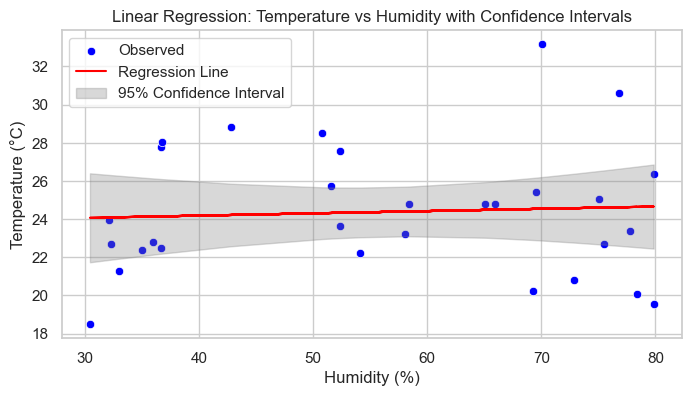

In [15]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Humidity', y='Temperature', data=df_merged, label='Observed', color='blue')
plt.plot(df_merged['Humidity'], df_merged['Predicted_Temp'], color='red', label='Regression Line')
df_sorted = df_merged.sort_values(by='Humidity')
plt.fill_between(x = df_sorted['Humidity'], y1 = df_sorted['CI_Lower'],  y2 = df_sorted['CI_Upper'], color='gray', alpha=0.3, label='95% Confidence Interval')
plt.title('Linear Regression: Temperature vs Humidity with Confidence Intervals')
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

<Figure size 800x400 with 0 Axes>

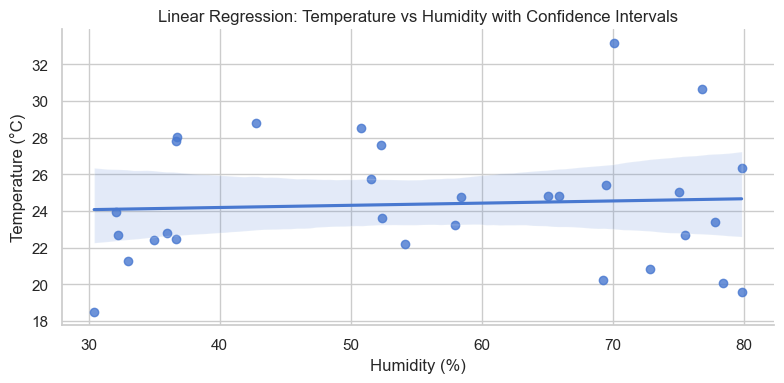

In [16]:
plt.figure(figsize=(8, 4))
sns.lmplot(x='Humidity', y='Temperature', data=df_merged, height = 4, aspect = 2)
plt.title('Linear Regression: Temperature vs Humidity with Confidence Intervals')
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

## 6. Advanced Regression with Diagnostics

We fit a multivariable model adding the heat index to investigate combined effects.
Diagnostic plots include residual analysis and QQ plots to assess normality.

### Visualization explanation:
- `sns.residplot()`: plots residuals as a function of fitted values.
   - `lowess=True` adds a locally weighted smoother line.
   - The red line shows average residual behavior.

- `sm.qqplot()`: quantile-quantile plot comparing residual distribution to a normal distribution.
   - A straight diagonal line suggests normally distributed residuals.


                            OLS Regression Results                            
Dep. Variable:            Temperature   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.179e+30
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        08:58:36   Log-Likelihood:                 929.99
No. Observations:                  30   AIC:                            -1854.
Df Residuals:                      27   BIC:                            -1850.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8.483e-15   1.26e-14     -0.672      0.5

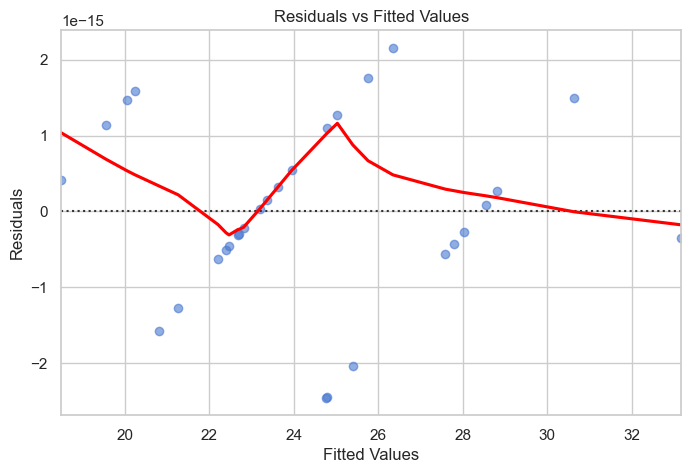

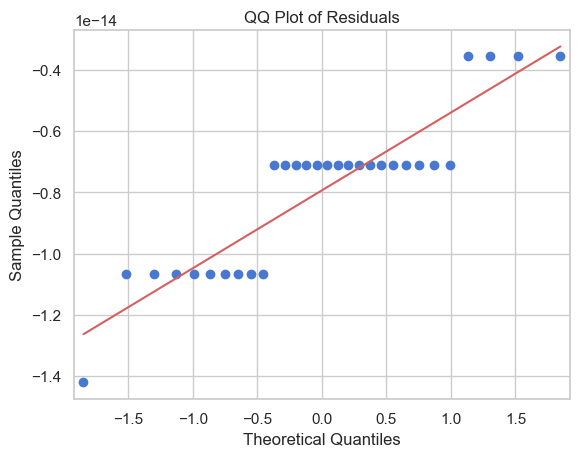

In [17]:
multi_model = smf.ols('Temperature ~ Humidity + Heat_Index', data=df_merged).fit()
print(multi_model.summary())

plt.figure(figsize=(8, 5))
sns.residplot(x=multi_model.fittedvalues, y=multi_model.resid, lowess=True,
              scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

sm.qqplot(multi_model.resid, line='s')
plt.title('QQ Plot of Residuals')
plt.show()

### Interpretation

- Coefficients and p-values indicate predictor importance.
- R² and Adjusted R² measure model fit quality.
- Confidence intervals express uncertainty in estimates.
- Visualization functions like `scatterplot`, `histplot`, and `residplot` provide intuitive understanding of patterns and model performance.
